In [1]:
import pandahouse 
import pandas as pd
import scipy.stats as stats 
from scipy.stats import norm, ttest_ind
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import hashlib # Делать хеши
import swifter # Для ускорения метода apply
from tqdm import tqdm # Для отслеживания прогресса

In [2]:
#создаём генератор псевдослучайных чисел
rng = np.random.default_rng()

<b>Задача

<b>К нам пришли наши коллеги из ML-отдела и рассказали, что планируют выкатывать новый алгоритм, рекомендующий нашим пользователям интересные посты. После обсуждений того, как он это делает, можно сделать следующие выводы:

<b>1.Алгоритм добавляет пользователям 1-2 просмотра
    
<b>2.Вероятность того, что он сработает, составляет 90%
    
<b>3.Если у пользователя меньше 50 просмотров, то алгоритм не сработает

Гипотеза: увеличение числа просмотров (views) приведёт и к увеличению лайков (likes) на пользователя. 

Можем ли мы обнаружить различия в среднем количестве лайков на пользователя? 
Для этого необходимо провести симуляцию Монте-Карло.

- Распределения, из которых мы будем симулировать просмотры и пользовательские CTR, мы построим на основе периода АА-теста (c '2025-03-21' по '2025-03-27'), когда новый алгоритм еще не применялся. Это исторические данные.

In [3]:
connection = {
    'host': 'http://clickhouse.lab.karpov.courses:8123',
    'password': 'dpo_python_2020',
    'user': 'student',
    'database': 'simulator'
}

<b>Определяем базовые исторические уровни метрик - просмотров views и CTR - и их p-распределение

<b>Распределение просмотров

In [4]:
#Просмотры views на 1 пользователя в течение недели

q = """
select views, count() as users
from (select  
    user_id,
    sum(action = 'view') as views
from simulator_20251220.feed_actions
where toDate(time) between '2025-11-14' and '2025-11-20'
group by user_id
)
group by views
order by views
"""

views_distribution = pandahouse.read_clickhouse(q, connection=connection)

In [5]:
views_distribution.head()

,views,users
0,1,4
1,2,1
2,3,4
3,4,5
4,5,18


In [6]:
#общее количество пользователей
views_distribution.users.sum()

41997

In [7]:
#нормируем на общее число всех пользователей, получаем вероятность этого значения
views_distribution['p'] = views_distribution['users']/views_distribution.users.sum()

In [8]:
views_distribution.sort_values(by = 'p', ascending = False)

,views,users,p
15,16,545,0.012977
14,15,537,0.012787
13,14,500,0.011906
34,35,485,0.011548
29,30,469,0.011167
...,...,...,...
280,287,1,0.000024
278,285,1,0.000024
276,280,1,0.000024
1,2,1,0.000024


In [9]:
#Наше настоящее распределение просмотров (до применения алгоритма) сделаем дискретным.
views_distr = stats.rv_discrete(name='views_distr', 
                                values=(views_distribution['views'], 
                                        views_distribution['p']))
# pd.DataFrame(data=views_distr)

In [10]:
#cреднее число просмотров = 70
views_distr.mean()

70.30916494035289

In [11]:
#среднее число просмотров по сгенерированной выборке при размере 100 = 75 - выше, при 1000 - 71,8 - уже лучше
views_distr.rvs(size = 1000).mean() 

68.01

In [12]:
#медиана просмотров = 60
views_distr.median()

60.0

In [13]:
#стандартное отклонение = 46,8
views_distr.std()

46.795649294309676

<Axes: ylabel='Count'>

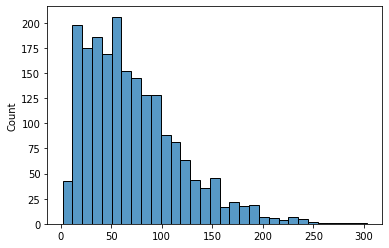

In [14]:
#Построим гистограмму просмотров
sns.histplot(views_distr.rvs(size=2000))

У нас есть ограничение по количеству просмотров, когда новый алгоритм не будет работать - 50 просмотров. Судя по гистограмме, под ограничение попадает большое число пользователей (максимальные частоты сосредоточены на малых значениях просмотров).

<b>Распределение CTR

In [15]:
#CTR за неделю

q = """
select 
   floor(ctr, 2) as ctr, count() as users
from (select toDate(time) as dt, 
    user_id,
    sum(action = 'like')/sum(action = 'view') as ctr
from simulator_20251220.feed_actions
where dt between '2025-11-14' and '2025-11-20'
group by dt, exp_group, user_id
)
group by ctr
order by users desc
"""

ctr_distribution = pandahouse.read_clickhouse(q, connection=connection)

In [16]:
#нормируем на общее число всех пользователей - получаем вероятность этого значения
ctr_distribution['p'] = ctr_distribution['users']/ctr_distribution.users.sum()

In [17]:
ctr_distribution.sort_values(by = 'p', ascending = False)

,ctr,users,p
0,0.20,4993,0.058658
1,0.16,4233,0.049729
2,0.25,4216,0.049529
3,0.18,4213,0.049494
4,0.21,3957,0.046487
...,...,...,...
75,0.81,2,0.000023
76,0.83,1,0.000012
77,0.88,1,0.000012
78,1.00,1,0.000012


In [18]:
ctr_distribution['p']

0     0.058658
1     0.049729
2     0.049529
3     0.049494
4     0.046487
        ...   
75    0.000023
76    0.000012
77    0.000012
78    0.000012
79    0.000012
Name: p, Length: 80, dtype: float64

In [19]:
#Наше настоящее распределение CTR до применения алгоритма сделаем дискретным
ctr_distr = stats.rv_discrete(name='ctr_distr', 
                                values=(ctr_distribution['ctr'], 
                                        ctr_distribution['p']))

In [20]:
#cреднее значение CTR = 0,21
ctr_distr.mean()

0.21222988451733416

In [21]:
#количество симуляций = 20000 
#размер_выборки = 20998 (количество пользователей за неделю разбили на 2 группы)
num_simulations = 20000
num_group = 20998
num_group = 30591
p_values = [] #все значения
for _ in tqdm(range(num_simulations)):
    group_A_views = rng.choice(views_distribution['views'], size=num_group, p=views_distribution['p']).astype(np.int64)
    group_B_views = rng.choice(views_distribution['views'], size=num_group, p=views_distribution['p']).astype(np.int64)

    group_B_views = group_B_views + (
    (1 + rng.binomial(n=1, p=0.5, size=num_group)) * 
    rng.binomial(n=1, p=0.9, size=num_group) * 
    (group_B_views >= 30))

    group_A_ctr = rng.choice(ctr_distribution['ctr'], size=num_group, p=ctr_distribution['p'])    
    group_B_ctr = rng.choice(ctr_distribution['ctr'], size=num_group, p=ctr_distribution['p'])
    group_A_likes = rng.binomial(group_A_views, group_A_ctr)
    group_B_likes = rng.binomial(group_B_views, group_B_ctr) 
    
    mask_A = group_A_views >= 30
    mask_B = group_B_views >= 30

    # scipy.stats.ttest_ind(group_A_likes[mask_A], group_B_likes[mask_B], equal_var=False)
    
    p_values.append(stats.ttest_ind(group_A_likes[mask_A], group_B_likes[mask_B], equal_var=False).pvalue)
    
a = round((np.mean(np.array(p_values) < 0.05)*100), 1)
a

100%|██████████| 20000/20000 [08:12<00:00, 40.64it/s]


64.5

In [45]:
p_values[0:5]

[0.7117504293482151,
 0.1283871683584576,
 0.1348380597410226,
 0.013666205377077089,
 0.0024597688669196964]

In [81]:
#мощность теста
a = round((np.mean(np.array(p_values) < 0.05)*100), 1)
a

35.1

мощность теста - это вероятность того, что статистический тест правильно отвергнет нулевую гипотезу (H₀), когда она на самом деле ложная. Иными словами, мощность теста показывает, насколько тест эффективен в выявлении реальных эффектов или различий, если они существуют.